In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import yfinance as yf
import os
# If mplfinance is not installed, run:
# !pip install mplfinance
import mplfinance as mpf

from tensorflow.keras import mixed_precision
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.layers import GRU, SimpleRNN, Input


In [2]:
# Mixed precision setting

In [3]:
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

In [4]:
## Stock selection and training period

# Here I define the stock ticker and the period used for training data.

In [5]:
COMPANY = 'CBA.AX'

TRAIN_START = '2020-01-01'
TRAIN_END = '2023-08-01'

TEST_START = '2023-08-02'
TEST_END = '2024-07-02'

In [6]:
## Download training data

In [7]:
data = yf.download(COMPANY, TRAIN_START, TRAIN_END)
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,CBA.AX,CBA.AX,CBA.AX,CBA.AX,CBA.AX
Date,,,,,
2020-01-02,63.102222,63.370813,62.715142,63.031129,1416232
2020-01-03,63.441914,64.137085,63.394518,63.963292,1622784
2020-01-06,63.015327,63.102224,62.588753,62.983734,2129260
2020-01-07,64.144981,64.144981,63.339222,63.844798,2417468
2020-01-08,63.907986,64.184471,63.220716,64.160774,1719114


In [8]:
## Data preparation function

In [9]:
def load_and_prepare_multi_feature_data(
    data,
    feature_columns=['Close', 'Volume', 'High', 'Low'],
    target_column='Close',
    prediction_days=60
):
    # Keep only the selected columns
    dataset = data[feature_columns].copy()

    # Fill missing values before training
    dataset = dataset.ffill().bfill()

    # Safety check
    if dataset.isnull().sum().sum() > 0:
        raise ValueError("Dataset still contains NaN values after preprocessing.")

    # Scale all features to the range (0, 1)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(dataset)

    # Create input sequences and target values
    x_train = []
    y_train = []

    target_index = feature_columns.index(target_column)

    for i in range(prediction_days, len(scaled_data)):
        x_train.append(scaled_data[i - prediction_days:i])
        y_train.append(scaled_data[i, target_index])

    x_train = np.array(x_train)
    y_train = np.array(y_train)

    return x_train, y_train, scaler, dataset

In [10]:
# Helper function for yfinance columns

In [11]:
def flatten_yfinance_columns(df):
    """
    Make sure yfinance columns are simple one-level names.
    This helps avoid plotting issues.
    """
    df = df.copy()

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    return df

In [12]:
def load_and_prepare_multistep_multivariate_data(
    data,
    feature_columns=['Close', 'Volume', 'High', 'Low'],
    target_column='Close',
    prediction_days=60,
    future_days=5
):
    """
    Prepare multivariate input and multistep output data.

    Input:
        previous 'prediction_days' days of multiple features

    Output:
        next 'future_days' values of the target column
    """

    dataset = flatten_yfinance_columns(data)[feature_columns].copy()
    dataset = dataset.ffill().bfill()

    if dataset.isnull().sum().sum() > 0:
        raise ValueError("Dataset still contains NaN values after preprocessing.")

    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(dataset)

    x_train = []
    y_train = []

    target_index = feature_columns.index(target_column)

    for i in range(prediction_days, len(scaled_data) - future_days + 1):
        x_train.append(scaled_data[i - prediction_days:i])
        y_train.append(scaled_data[i:i + future_days, target_index])

    x_train = np.array(x_train)
    y_train = np.array(y_train)

    return x_train, y_train, scaler, dataset

def build_dynamic_dl_model(
    model_type='LSTM',
    input_shape=(60, 4),
    units=50,
    dropout_rate=0.2,
    num_layers=3,
    output_steps=1
):
    """
    Build a deep learning model dynamically.

    model_type:
        'LSTM', 'GRU', or 'RNN'

    output_steps:
        number of future days to predict
    """

    model_type = model_type.upper()

    layer_map = {
        'LSTM': LSTM,
        'GRU': GRU,
        'RNN': SimpleRNN
    }

    if model_type not in layer_map:
        raise ValueError("model_type must be 'LSTM', 'GRU', or 'RNN'.")

    RecurrentLayer = layer_map[model_type]

    model = Sequential()
    model.add(Input(shape=input_shape))

    for layer_num in range(num_layers):
        return_sequences = layer_num < num_layers - 1
        model.add(RecurrentLayer(units=units, return_sequences=return_sequences))
        model.add(Dropout(dropout_rate))

    model.add(Dense(units=output_steps))
    model.compile(optimizer='adam', loss='mean_squared_error')

    return model

def predict_next_k_days(
    model,
    scaled_feature_data,
    scaler,
    feature_columns,
    target_column='Close',
    prediction_days=60
):
    """
    Predict the next k future closing prices from the latest window.
    """

    recent_window = scaled_feature_data[-prediction_days:]
    recent_window = np.array([recent_window])

    predicted_scaled = model.predict(recent_window)

    target_index = feature_columns.index(target_column)

    dummy = np.zeros((predicted_scaled.shape[1], len(feature_columns)))
    dummy[:, target_index] = predicted_scaled[0]

    predicted_prices = scaler.inverse_transform(dummy)[:, target_index]

    return predicted_prices

In [13]:
# Candlestick chart function

In [14]:
def plot_and_save_candlestick_chart(
    data,
    company='CBA.AX',
    last_n_days=60,
    save_path='candlestick_chart.png'
):
    """
    Plot and save a candlestick chart.

    What this function does:
    - keeps the OHLC data needed for candlestick plotting
    - selects the most recent n days
    - draws the candlestick chart
    - saves it as an image file
    """

    chart_data = flatten_yfinance_columns(data)

    required_columns = ['Open', 'High', 'Low', 'Close']
    missing_columns = [col for col in required_columns if col not in chart_data.columns]

    if missing_columns:
        raise ValueError(f"Missing required columns for candlestick chart: {missing_columns}")

    columns_to_use = ['Open', 'High', 'Low', 'Close']
    if 'Volume' in chart_data.columns:
        columns_to_use.append('Volume')

    chart_data = chart_data[columns_to_use].tail(last_n_days)

    fig, axes = mpf.plot(
        chart_data,
        type='candle',
        style='yahoo',
        volume='Volume' in chart_data.columns,
        title=f"{company} Candlestick Chart",
        ylabel='Price',
        ylabel_lower='Volume',
        figsize=(12, 6),
        returnfig=True
    )

    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    return save_path

In [15]:
# Moving-window Boxplot function

In [16]:
def plot_and_save_moving_window_boxplot(
    data,
    price_column='Close',
    window_size=20,
    step=5,
    company='CBA.AX',
    save_path='moving_boxplot.png'
):
    """
    Plot and save a moving-window boxplot.

    What this function does:
    - takes one price column, usually Close
    - splits it into rolling windows
    - draws one boxplot for each window
    - saves the plot as an image file

    window_size:
        number of days inside each boxplot window

    step:
        how many days to move forward before drawing the next window
    """

    plot_data = flatten_yfinance_columns(data)

    if price_column not in plot_data.columns:
        raise ValueError(f"Column '{price_column}' not found in data.")

    prices = plot_data[price_column].dropna()

    if len(prices) < window_size:
        raise ValueError("Not enough data for the selected window size.")

    windows = []
    labels = []

    for start in range(0, len(prices) - window_size + 1, step):
        end = start + window_size

        window_values = prices.iloc[start:end].values
        windows.append(window_values)

        start_date = prices.index[start].strftime('%Y-%m-%d')
        end_date = prices.index[end - 1].strftime('%Y-%m-%d')
        labels.append(f"{start_date}\n{end_date}")

    plt.figure(figsize=(13, 6))
    plt.boxplot(windows, showfliers=False)

    # Only show some labels so the chart stays readable
    tick_positions = list(range(1, len(labels) + 1))
    show_every = max(1, len(labels) // 8)
    sparse_labels = [labels[i - 1] if (i - 1) % show_every == 0 else '' for i in tick_positions]

    plt.xticks(tick_positions, sparse_labels, rotation=45)
    plt.title(f"{company} Moving Window Boxplot ({window_size}-Day Windows)")
    plt.xlabel("Rolling Time Windows")
    plt.ylabel(f"{price_column} Price")
    plt.tight_layout()

    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    return save_path

In [17]:
## Prepare training data

# The model uses four input features:
# - Close
# - Volume
# - High
# - Low

# The target value remains the closing price.

In [18]:
FEATURE_COLUMNS = ['Close', 'Volume', 'High', 'Low']
TARGET_COLUMN = 'Close'
PREDICTION_DAYS = 60

x_train, y_train, scaler, cleaned_data = load_and_prepare_multi_feature_data(
    data=data,
    feature_columns=FEATURE_COLUMNS,
    target_column=TARGET_COLUMN,
    prediction_days=PREDICTION_DAYS
)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

x_train shape: (845, 60, 4)
y_train shape: (845,)


In [19]:
### What these shapes mean

# - `x_train` contains the training sequences  
# - each sequence uses 60 previous trading days  
# - each day has 4 features  
# - `y_train` contains the value to predict, which is the closing price

In [20]:
## Build the LSTM model

# This model uses stacked LSTM layers to learn price patterns over time.

# - LSTM layers learn from sequential data
# - Dropout layers help reduce overfitting
# - the final Dense layer outputs one predicted value

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, GRU

def build_seq_model(model_type, input_shape, units=50, dropout=0.2):
    RNN = LSTM if model_type.upper() == "LSTM" else GRU

    model = Sequential()
    model.add(RNN(units=units, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(dropout))

    model.add(RNN(units=units, return_sequences=True))
    model.add(Dropout(dropout))

    model.add(RNN(units=units))
    model.add(Dropout(dropout))

    model.add(Dense(1))
    model.compile(optimizer="adam", loss="mean_squared_error")
    return model

In [22]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=50))
model.add(Dropout(0.2))

model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

D:\anaconda3\envs\COS30018\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,451 (200.98 KB)

 Trainable params: 51,451 (200.98 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
## Train the model

# The model is trained for 30 epochs using batch size 32.

In [24]:
import time

start = time.perf_counter()
history = model.fit(x_train, y_train, epochs=20, batch_size=32, verbose=1)
train_time = time.perf_counter() - start

print("Train time (sec):", train_time)

Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - loss: 0.0412
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - loss: 0.0094
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 131ms/step - loss: 0.0071
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - loss: 0.0073
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - loss: 0.0066
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - loss: 0.0060
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - loss: 0.0071
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - loss: 0.0063
Epoch 9/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - loss: 0.0064
Epoch 10/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - loss: 0.0059
Epoch 11/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - loss: 0.0066
Epoch 12/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - loss: 0.0060
Epoch 13/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step - loss: 0.0062
Epoch 14/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - loss: 0.0061
Epoch 15/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - lo

In [25]:
## Download test data

In [26]:
test_data = yf.download(COMPANY, TEST_START, TEST_END)
test_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,CBA.AX,CBA.AX,CBA.AX,CBA.AX,CBA.AX
Date,,,,,
2023-08-02,93.369171,95.074832,93.035256,94.966540,2074443
2023-08-03,92.466698,93.260866,92.105710,92.917931,2890772
2023-08-04,91.934242,93.089398,91.780818,92.683284,2687798
2023-08-07,91.916183,92.250098,91.591295,92.132773,2771020
2023-08-08,92.241074,92.574989,91.988384,92.412544,3241229


In [27]:
## Prepare test inputs
# This section:
# - keeps the same selected features
# - combines training and test data
# - takes the last 60 days before each prediction
# - applies the same scaler used during training

In [28]:
actual_prices = test_data[TARGET_COLUMN].values

total_dataset = pd.concat((data[FEATURE_COLUMNS], test_data[FEATURE_COLUMNS]), axis=0)

model_inputs = total_dataset[len(total_dataset) - len(test_data) - PREDICTION_DAYS:].copy()
model_inputs = model_inputs.ffill().bfill()
model_inputs = scaler.transform(model_inputs)

In [29]:
## Create test sequences and make predictions

# The loop below creates input sequences for the test set.

# Each test sample contains:
# - 60 previous days
# - 4 features for each day

# The model outputs predictions in scaled form, so the results are converted back to the original price scale. 

In [30]:
x_test = []

for x in range(PREDICTION_DAYS, len(model_inputs)):
    x_test.append(model_inputs[x - PREDICTION_DAYS:x])

x_test = np.array(x_test)

predicted_scaled = model.predict(x_test)

target_index = FEATURE_COLUMNS.index(TARGET_COLUMN)

dummy = np.zeros((len(predicted_scaled), len(FEATURE_COLUMNS)))
dummy[:, target_index] = predicted_scaled[:, 0]

predicted_prices = scaler.inverse_transform(dummy)[:, target_index]

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step


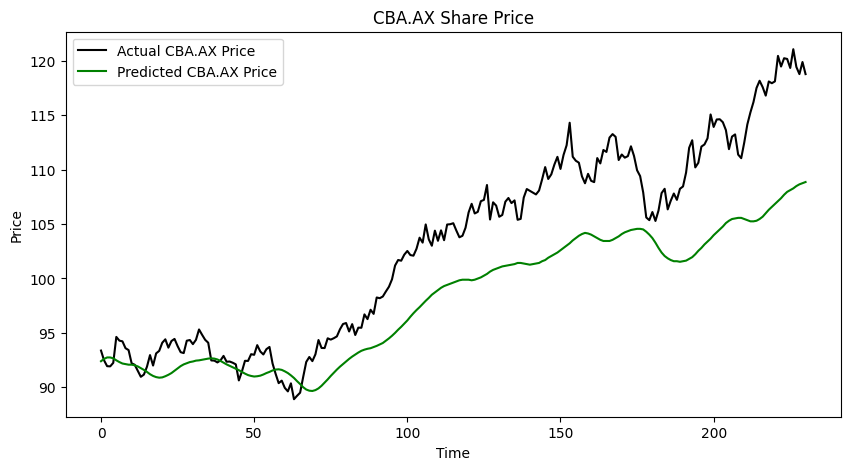

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted next closing price: 108.91219471767545


In [31]:
## Compare actual and predicted prices
plt.figure(figsize=(10, 5))
plt.plot(actual_prices, color="black", label=f"Actual {COMPANY} Price")
plt.plot(predicted_prices, color="green", label=f"Predicted {COMPANY} Price")
plt.title(f"{COMPANY} Share Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

## Predict the next trading day

# This section uses the latest 60 days of input data to estimate the next closing price.
real_data = [model_inputs[len(model_inputs) - PREDICTION_DAYS:]]
real_data = np.array(real_data)

prediction_scaled = model.predict(real_data)

dummy = np.zeros((1, len(FEATURE_COLUMNS)))
dummy[0, target_index] = prediction_scaled[0, 0]

prediction = scaler.inverse_transform(dummy)[:, target_index]
print(f"Predicted next closing price: {prediction[0]}")

In [32]:
# Week 8: Metrics (MAE/MSE)

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(actual_prices, predicted_prices)
mse = mean_squared_error(actual_prices, predicted_prices)

print("Test MAE:", mae)
print("Test MSE:", mse)

Test MAE: 5.0662481832555875
Test MSE: 36.88171563716292


In [34]:
# Week 6: Visualization & Segmentation 

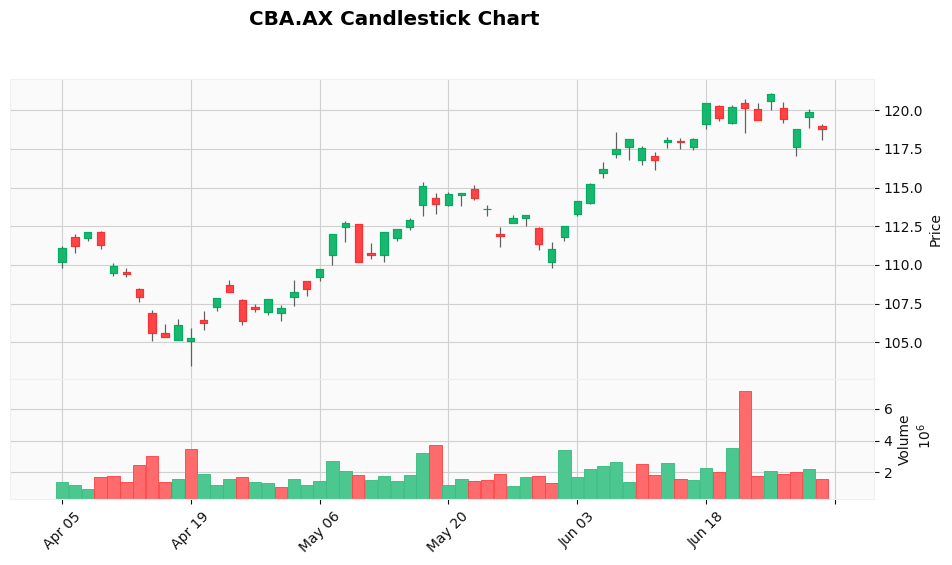

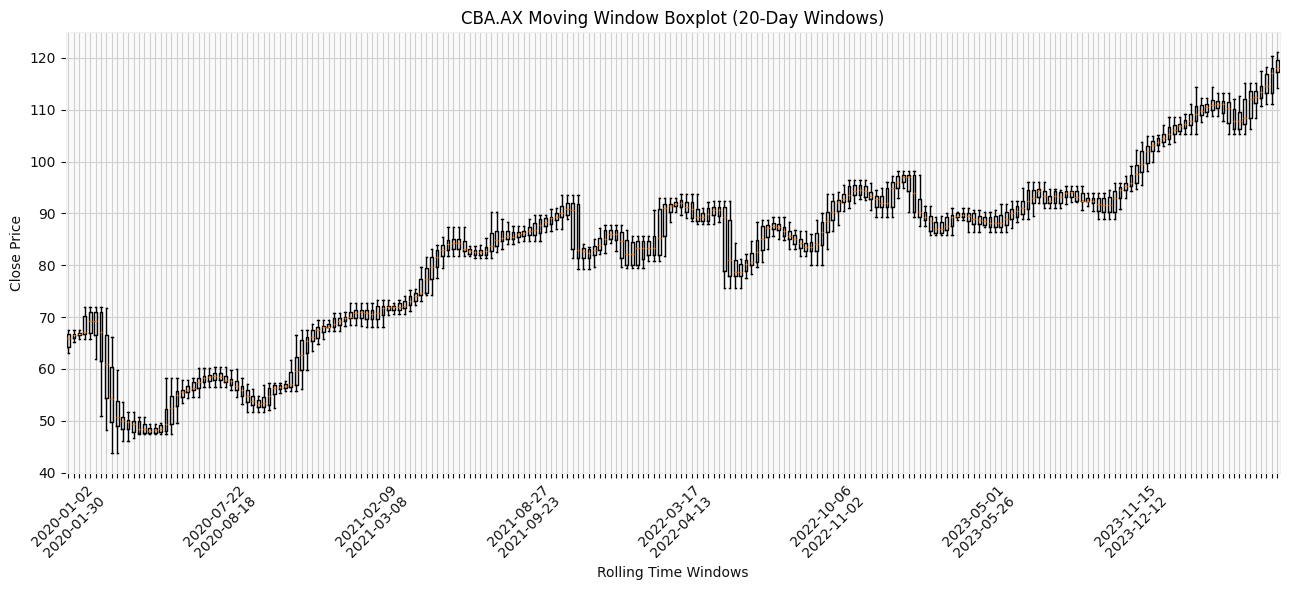

Saved: cba_candlestick_chart.png
Saved: cba_moving_boxplot.png


In [35]:
full_data = pd.concat([data, test_data])
full_data = full_data[~full_data.index.duplicated(keep='first')]

candlestick_file = plot_and_save_candlestick_chart(
    full_data,
    company=COMPANY,
    last_n_days=60,
    save_path='cba_candlestick_chart.png'
)

boxplot_file = plot_and_save_moving_window_boxplot(
    full_data,
    price_column='Close',
    window_size=20,
    step=5,
    company=COMPANY,
    save_path='cba_moving_boxplot.png'
)

print("Saved:", candlestick_file)
print("Saved:", boxplot_file)

# from IPython.display import Image, display

# display(Image(filename=candlestick_file))
# display(Image(filename=boxplot_file))

In [36]:
# Week 7: Dynamic Models, Multistep and Multivariate Prediction

In [37]:
W7_FEATURE_COLUMNS = ['Close', 'Volume', 'High', 'Low']
W7_TARGET_COLUMN = 'Close'
W7_PREDICTION_DAYS = 60
W7_FUTURE_DAYS = 5          # predict next 5 days
W7_MODEL_TYPE = 'GRU'       # try 'LSTM', 'GRU', or 'RNN'

# Prepare Week 7 task training data

x_train_w7, y_train_w7, scaler_w7, cleaned_data_w7 = load_and_prepare_multistep_multivariate_data(
    data=data,
    feature_columns=W7_FEATURE_COLUMNS,
    target_column=W7_TARGET_COLUMN,
    prediction_days=W7_PREDICTION_DAYS,
    future_days=W7_FUTURE_DAYS
)

print("x_train_w7 shape:", x_train_w7.shape)
print("y_train_w7 shape:", y_train_w7.shape)

# Build the model dynamically

week7_model = build_dynamic_dl_model(
    model_type=W7_MODEL_TYPE,
    input_shape=(x_train_w7.shape[1], x_train_w7.shape[2]),
    units=50,
    dropout_rate=0.2,
    num_layers=3,
    output_steps=W7_FUTURE_DAYS
)

week7_model.summary()

x_train_w7 shape: (841, 60, 4)
y_train_w7 shape: (841, 5)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 50)         │         8,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 60, 50)         │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,255 (153.34 KB)

 Trainable params: 39,255 (153.34 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Train the Week 7 model

In [39]:
history_w7 = week7_model.fit(
    x_train_w7,
    y_train_w7,
    epochs=20,
    batch_size=32
)

Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - loss: 0.1251
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - loss: 0.0263
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - loss: 0.0191
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - loss: 0.0171
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0152
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - loss: 0.0146
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - loss: 0.0133
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - loss: 0.0127
Epoch 9/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - loss: 0.0111
Epoch 10/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - loss: 0.0119
Epoch 11/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - loss: 0.0105
Epoch 12/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - loss: 0.0108
Epoch 13/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - loss: 0.0095
Epoch 14/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - loss: 0.0099
Epoch 15/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - lo

In [40]:
# Evaluate Week 7 model on the first 5 known days of the test set

train_eval_features = data[W7_FEATURE_COLUMNS].copy()
train_eval_features = train_eval_features.ffill().bfill()

scaled_train_eval_features = scaler_w7.transform(train_eval_features)

predicted_first_5_test_days = predict_next_k_days(
    model=week7_model,
    scaled_feature_data=scaled_train_eval_features,
    scaler=scaler_w7,
    feature_columns=W7_FEATURE_COLUMNS,
    target_column=W7_TARGET_COLUMN,
    prediction_days=W7_PREDICTION_DAYS
)

actual_first_5_test_days = test_data[W7_TARGET_COLUMN].values[:W7_FUTURE_DAYS]

print("Predicted first 5 test days:", predicted_first_5_test_days)
print("Actual first 5 test days:   ", actual_first_5_test_days)

D:\anaconda3\envs\COS30018\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 538ms/step
Predicted first 5 test days: [95.71075497 96.50762256 95.55138145 96.74668284 96.26856228]
Actual first 5 test days:    [[93.36917114]
 [92.46669769]
 [91.93424225]
 [91.91618347]
 [92.24107361]]


In [41]:
# predict the next k days

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Next 5 predicted closing prices:
[116.7214971  117.94336074 116.34962556 118.10273426 116.82774612]


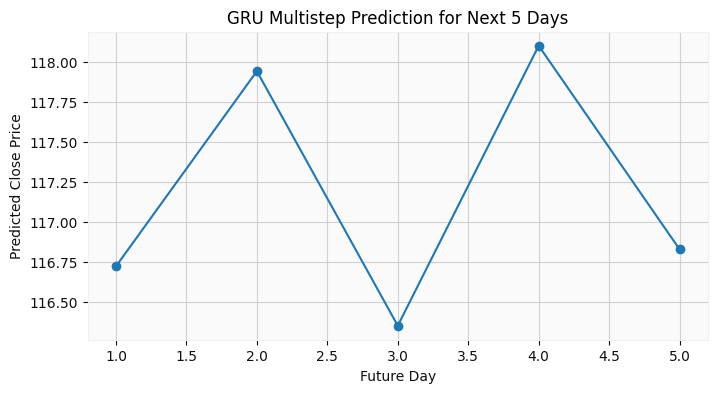

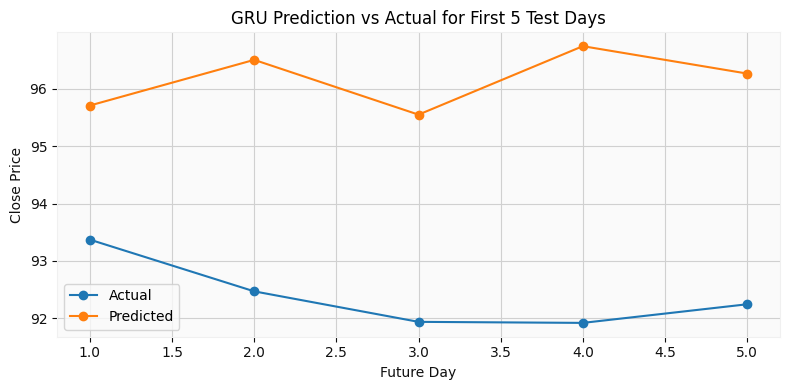

In [42]:
week7_full_data = pd.concat([data, test_data])
week7_full_data = week7_full_data[~week7_full_data.index.duplicated(keep='first')]
week7_full_data = flatten_yfinance_columns(week7_full_data)

week7_features = week7_full_data[W7_FEATURE_COLUMNS].copy()
week7_features = week7_features.ffill().bfill()

scaled_week7_features = scaler_w7.transform(week7_features)

next_k_predictions = predict_next_k_days(
    model=week7_model,
    scaled_feature_data=scaled_week7_features,
    scaler=scaler_w7,
    feature_columns=W7_FEATURE_COLUMNS,
    target_column=W7_TARGET_COLUMN,
    prediction_days=W7_PREDICTION_DAYS
)

print(f"Next {W7_FUTURE_DAYS} predicted closing prices:")
print(next_k_predictions)

plt.figure(figsize=(8, 4))
plt.plot(range(1, W7_FUTURE_DAYS + 1), next_k_predictions, marker='o')
plt.title(f"{W7_MODEL_TYPE} Multistep Prediction for Next {W7_FUTURE_DAYS} Days")
plt.xlabel("Future Day")
plt.ylabel("Predicted Close Price")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(range(1, W7_FUTURE_DAYS + 1), actual_first_5_test_days, marker='o', label='Actual')
plt.plot(range(1, W7_FUTURE_DAYS + 1), predicted_first_5_test_days, marker='o', label='Predicted')
plt.title(f"{W7_MODEL_TYPE} Prediction vs Actual for First {W7_FUTURE_DAYS} Test Days")
plt.xlabel("Future Day")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()